In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")

#Add the path for the feature-engineered data
DATA_PROCESSED_PATH = os.getenv("DATA_PROCESSED_PATH", "../data/processed/")    
X_TRAIN_DATA_FILENAME = os.getenv("X_TRAIN_DATA_FILENAME", "X_train.csv")
X_TEST_DATA_FILENAME = os.getenv("X_TEST_DATA_FILENAME", "X_test.csv")
Y_TRAIN_LOG_DATA_FILENAME = os.getenv("Y_TRAIN_LOG_DATA_FILENAME", "y_train_log.csv")
Y_TEST_LOG_DATA_FILENAME = os.getenv("Y_TEST_LOG_DATA_FILENAME", "y_test_log.csv")
Y_TRAIN_ACTUAL_DATA_FILENAME = os.getenv("Y_TRAIN_ACTUAL_DATA_FILENAME", "y_train_actual.csv")
Y_TEST_ACTUAL_DATA_FILENAME = os.getenv("Y_TEST_ACTUAL_DATA_FILENAME", "y_test_actual.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")


✅ Environment setup complete!


In [2]:
from pathlib import Path
import os

data_path = Path("../data/processed/feature_engineered_house_data.csv")
print(data_path.exists())
print(os.path.exists(data_path))

True
True


In [3]:
# Load your feature-engineered dataset
data_path = Path(DATA_PROCESSED_PATH)
X_train = pd.read_csv(data_path / X_TRAIN_DATA_FILENAME)
X_test = pd.read_csv(data_path / X_TEST_DATA_FILENAME)
y_train_log = pd.read_csv(data_path / Y_TRAIN_LOG_DATA_FILENAME)
y_test_log = pd.read_csv(data_path / Y_TEST_LOG_DATA_FILENAME)
y_train_actual = pd.read_csv(data_path / Y_TRAIN_ACTUAL_DATA_FILENAME)
y_test_actual = pd.read_csv(data_path / Y_TEST_ACTUAL_DATA_FILENAME)


# Print the dataset shape for X_train and X_test,Y_train_log, y_train_actual, y_test_actual

print(f"Dataset shape: {X_train.shape}")
print(f"Dataset shape: {X_test.shape}")
print(f"Dataset shape: {y_train_log.shape}")
print(f"Dataset shape: {y_test_log.shape}")
print(f"Dataset shape: {y_train_actual.shape}")
print(f"Dataset shape: {y_test_actual.shape}")  

#print columns of the dataset for X_train and X_test, y_train_log, y_train_actual, y_test_actual
print("\n--- Dataset Columns ---")
print(X_train.columns)
print(X_test.columns)
print(y_train_log.columns)
print(y_test_log.columns)
print(y_train_actual.columns)
print(y_test_actual.columns)    



Dataset shape: (3681, 17)
Dataset shape: (921, 17)
Dataset shape: (3681, 1)
Dataset shape: (921, 1)
Dataset shape: (3681, 1)
Dataset shape: (921, 1)

--- Dataset Columns ---
Index(['log_sqft_living', 'log_sqft_lot', 'log_sqft_basement',
       'sqft_per_bedroom', 'basement_ratio', 'bedrooms_per_sqft',
       'bathrooms_per_sqft', 'house_age', 'floors', 'view', 'condition',
       'renovated', 'bath_x_living', 'waterfront_x_living', 'city_price_index',
       'statezip_price_index', 'knn_price'],
      dtype='object')
Index(['log_sqft_living', 'log_sqft_lot', 'log_sqft_basement',
       'sqft_per_bedroom', 'basement_ratio', 'bedrooms_per_sqft',
       'bathrooms_per_sqft', 'house_age', 'floors', 'view', 'condition',
       'renovated', 'bath_x_living', 'waterfront_x_living', 'city_price_index',
       'statezip_price_index', 'knn_price'],
      dtype='object')
Index(['log_price'], dtype='object')
Index(['log_price'], dtype='object')
Index(['price'], dtype='object')
Index(['price'], dtyp

In [4]:
# Align columns just in case
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# y_train = train_df['log_price']
# y_test = test_df['log_price']
# train_price = train_df['price']
# test_price = test_df['price']

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Number of features:', X_train.shape[1])
print(X_test.head())
print (X_train.head())

X_train shape: (3681, 17)
X_test shape: (921, 17)
Number of features: 17
   log_sqft_living  log_sqft_lot  log_sqft_basement  sqft_per_bedroom  \
0         7.286876      7.386471           5.638355             365.0   
1         8.033009      9.431642           0.000000             770.0   
2         7.986505      8.600247           6.216606             735.0   
3         7.696667      8.902592           6.447306             550.0   
4         7.450661      9.077494           6.580639             430.0   

   basement_ratio  bedrooms_per_sqft  bathrooms_per_sqft  house_age  floors  \
0        0.191650           0.002053            0.001711          7     2.0   
1        0.000000           0.000974            0.000811         24     2.0   
2        0.170010           0.001020            0.001105         36     3.0   
3        0.286234           0.001363            0.001136         26     1.0   
4        0.418361           0.001743            0.001453         31     1.0   

   view  cond

In [5]:
# Baseline and regularized linear models
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_percentage_error

# Function to evaluate models
def evaluate_log_model(model, X_train, y_train_log, X_test, y_test_actual, y_train_actual, fit_model=True):
    """
    Evaluates models trained on Natural Log scale (np.log).
    Returns MAPE in actual dollars.
    """
    if fit_model:
        # Flatten target to 1D to avoid warnings
        y_train_flat = y_train_log.values.ravel() if hasattr(y_train_log, 'values') else np.ravel(y_train_log)
        model.fit(X_train, y_train_flat)

    # 1. Predict (output is in natural log)
    pred_log_train = model.predict(X_train)
    pred_log_test = model.predict(X_test)
    
    # 2. Inverse Transform: e^x (The inverse of np.log)
    pred_price_train = np.exp(pred_log_train)
    pred_price_test = np.exp(pred_log_test)

    # 3. Calculate MAPE (Actual $ vs Predicted $)
    train_mape = mean_absolute_percentage_error(y_train_actual, pred_price_train)
    test_mape = mean_absolute_percentage_error(y_test_actual, pred_price_test)
    
    return train_mape, test_mape



#Using same Engineering Feature on multiple model (approaches)

In [6]:
# linear Model Benchmarks

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

models_to_test = [
    ('OLS', LinearRegression()),
    ('Ridge', RidgeCV(alphas=np.logspace(-3, 3, 10))),
    ('Lasso', LassoCV(cv=5, random_state=42)),
    ('Elastic Net', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, 1], cv=5, random_state=42))
]

linear_results = []
for name, model_alg in models_to_test:
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', model_alg)])
    
    # Call the updated function
    tr_m, te_m = evaluate_log_model(
        pipeline, X_train, y_train_log, X_test, y_test_actual, y_train_actual
    )
    linear_results.append({'Model': name, 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})

# Display the leaderboard
linear_results_df = pd.DataFrame(linear_results).sort_values('Test_MAPE%')
print(linear_results_df)



         Model  Train_MAPE%  Test_MAPE%
0          OLS    22.982190   28.600504
2        Lasso    22.976969   28.646276
3  Elastic Net    22.976907   28.648078
1        Ridge    22.978262   28.651406


#Adjust the feature engineering before apply different model

In [7]:
# ── Structurally different linear approaches ──────────────────────────────
# Each model below differs in *form*, not just regularization strength:
#   1. Spline regression     – cubic B-splines let the linear model curve
#   2. Polynomial interactions – explicit pairwise cross-product features
#   3. Huber regression      – linear model trained with Huber loss (robust to outliers)
#   4. Quantile regression   – minimises MAE instead of MSE (median prediction)

from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from sklearn.linear_model import HuberRegressor, QuantileRegressor, RidgeCV, LassoCV

# Continuous-only columns for splines/poly (skip binary flags)
continuous_cols = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_basement',
    'sqft_per_bedroom', 'basement_ratio', 'bedrooms_per_sqft',
    'bathrooms_per_sqft', 'house_age', 'bath_x_living',
    'city_price_index', 'statezip_price_index', 'knn_price',
]
binary_cols = [c for c in X_train.columns if c not in continuous_cols]

# Helper: split-transform pipeline that applies splines/poly to continuous
# features and passes binary/ordinal features through unchanged
from sklearn.compose import ColumnTransformer

def make_ct(transformer):
    return ColumnTransformer([
        ('transform', transformer, continuous_cols),
        ('passthrough', 'passthrough', binary_cols),
    ])


extended_results = []

# ── 1. Spline Regression ───────────────────────────────────────────────────
# Cubic B-splines with 5 knots per continuous feature → ~60 basis columns
# Ridge then selects the smoothing.
spline_pipe = Pipeline([
    ('ct',     make_ct(Pipeline([
                    ('scaler', StandardScaler()),
                    ('spline', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
               ]))),
    ('scaler2', StandardScaler()),          # rescale after expansion
    ('model',  RidgeCV(alphas=np.logspace(-3, 4, 20))),
])
tr_m, te_m = evaluate_log_model(spline_pipe, X_train, y_train_log, X_test, y_test_actual, y_train_actual)
extended_results.append({'Model': 'Spline Basis + Ridge', 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})
print(f"Spline + Ridge  → Train {tr_m*100:.2f}%  Test {te_m*100:.2f}%")

# ── 2. Polynomial Interactions (degree-2 cross products) + Lasso ──────────
# Generates all pairwise products of continuous features (interaction_only)
# → ~66 new terms on top of originals. Lasso prunes irrelevant ones.
poly_pipe = Pipeline([
    ('ct',      make_ct(Pipeline([
                    ('scaler', StandardScaler()),
                    ('poly',   PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
                ]))),
    ('scaler2', StandardScaler()),
    ('model',   LassoCV(cv=5, random_state=42, max_iter=10000)),
])
tr_m, te_m = evaluate_log_model(poly_pipe, X_train, y_train_log, X_test, y_test_actual, y_train_actual)
extended_results.append({'Model': 'Poly Interactions + Lasso', 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})
print(f"Poly + Lasso    → Train {tr_m*100:.2f}%  Test {te_m*100:.2f}%")

# ── 3. Huber Regression (robust linear model) ─────────────────────────────
# Same linear form as OLS but uses Huber loss, making it less sensitive
# to luxury-home outliers in the residuals.
huber_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  HuberRegressor(epsilon=1.35, max_iter=500)),
])
tr_m, te_m = evaluate_log_model(huber_pipe, X_train, y_train_log, X_test, y_test_actual, y_train_actual)
extended_results.append({'Model': 'Huber Regression', 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})
print(f"Huber           → Train {tr_m*100:.2f}%  Test {te_m*100:.2f}%")

# ── 4. Quantile Regression at the median ──────────────────────────────────
# Minimises sum of absolute deviations instead of squared errors.
# For right-skewed price distributions the median is a more natural target.
quantile_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  QuantileRegressor(quantile=0.5, solver='highs')),
])
tr_m, te_m = evaluate_log_model(quantile_pipe, X_train, y_train_log, X_test, y_test_actual, y_train_actual)
extended_results.append({'Model': 'Quantile Regression (median)', 'Train_MAPE%': tr_m*100, 'Test_MAPE%': te_m*100})
print(f"Quantile (0.5)  → Train {tr_m*100:.2f}%  Test {te_m*100:.2f}%")

# ── Combined leaderboard ───────────────────────────────────────────────────
extended_df = pd.DataFrame(extended_results)
all_linear = pd.concat([linear_results_df, extended_df], ignore_index=True).sort_values('Test_MAPE%')
print("\n" + "="*55)
print("    LINEAR MODEL LEADERBOARD (ALL APPROACHES)")
print("="*55)
print(all_linear.to_string(index=False))
print("="*55)

# Update linear_results_df so the final comparison cell includes these models
linear_results_df = all_linear


Spline + Ridge  → Train 19.71%  Test 24.85%
Poly + Lasso    → Train 20.25%  Test 25.34%
Huber           → Train 23.66%  Test 30.87%
Quantile (0.5)  → Train 45.09%  Test 45.18%

    LINEAR MODEL LEADERBOARD (ALL APPROACHES)
                       Model  Train_MAPE%  Test_MAPE%
        Spline Basis + Ridge    19.709270   24.846122
   Poly Interactions + Lasso    20.254475   25.342062
                         OLS    22.982190   28.600504
                       Lasso    22.976969   28.646276
                 Elastic Net    22.976907   28.648078
                       Ridge    22.978262   28.651406
            Huber Regression    23.660516   30.868009
Quantile Regression (median)    45.087754   45.181244


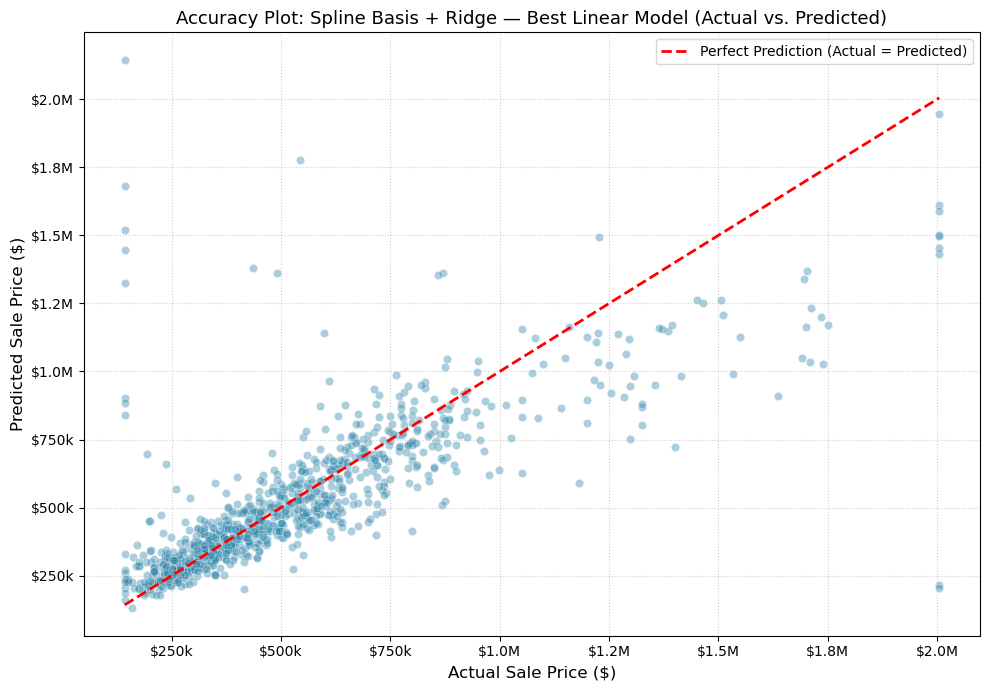

In [8]:
# Accuracy plot (Actual vs Predicted) for the BEST linear model: Spline Basis + Ridge

from matplotlib import ticker
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.compose import ColumnTransformer

# Continuous-only columns for splines (skip binary flags)
continuous_cols = [
    'log_sqft_living', 'log_sqft_lot', 'log_sqft_basement',
    'sqft_per_bedroom', 'basement_ratio', 'bedrooms_per_sqft',
    'bathrooms_per_sqft', 'house_age', 'bath_x_living',
    'city_price_index', 'statezip_price_index', 'knn_price',
]
binary_cols = [c for c in X_train.columns if c not in continuous_cols]

def make_ct(transformer):
    return ColumnTransformer([
        ('transform', transformer, continuous_cols),
        ('passthrough', 'passthrough', binary_cols),
    ])

# 1. Build and fit the Spline Basis + Ridge pipeline
spline_ridge_pipeline = Pipeline([
    ('ct', make_ct(Pipeline([
                    ('scaler', StandardScaler()),
                    ('spline', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
               ]))),
    ('scaler2', StandardScaler()),
    ('model', RidgeCV(alphas=np.logspace(-3, 4, 20))),
])

spline_ridge_pipeline.fit(X_train, y_train_log.values.ravel())

# 2. Predict and Inverse Transform
y_pred_log = spline_ridge_pipeline.predict(X_test)
y_pred_dollars = np.exp(y_pred_log).ravel()
y_actual_dollars = np.ravel(y_test_actual)

# 3. Create the Visualization
plt.figure(figsize=(10, 7))

# Scatter plot: Actual vs Predicted
sns.scatterplot(x=y_actual_dollars, y=y_pred_dollars, alpha=0.4, color='#2e86ab', edgecolor='w')

# 4. Add the 'Perfect Prediction' reference line
line_range = [y_actual_dollars.min(), y_actual_dollars.max()]
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Prediction (Actual = Predicted)')

# 5. Formatting
plt.title('Accuracy Plot: Spline Basis + Ridge — Best Linear Model (Actual vs. Predicted)', fontsize=13)
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)

formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}k')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



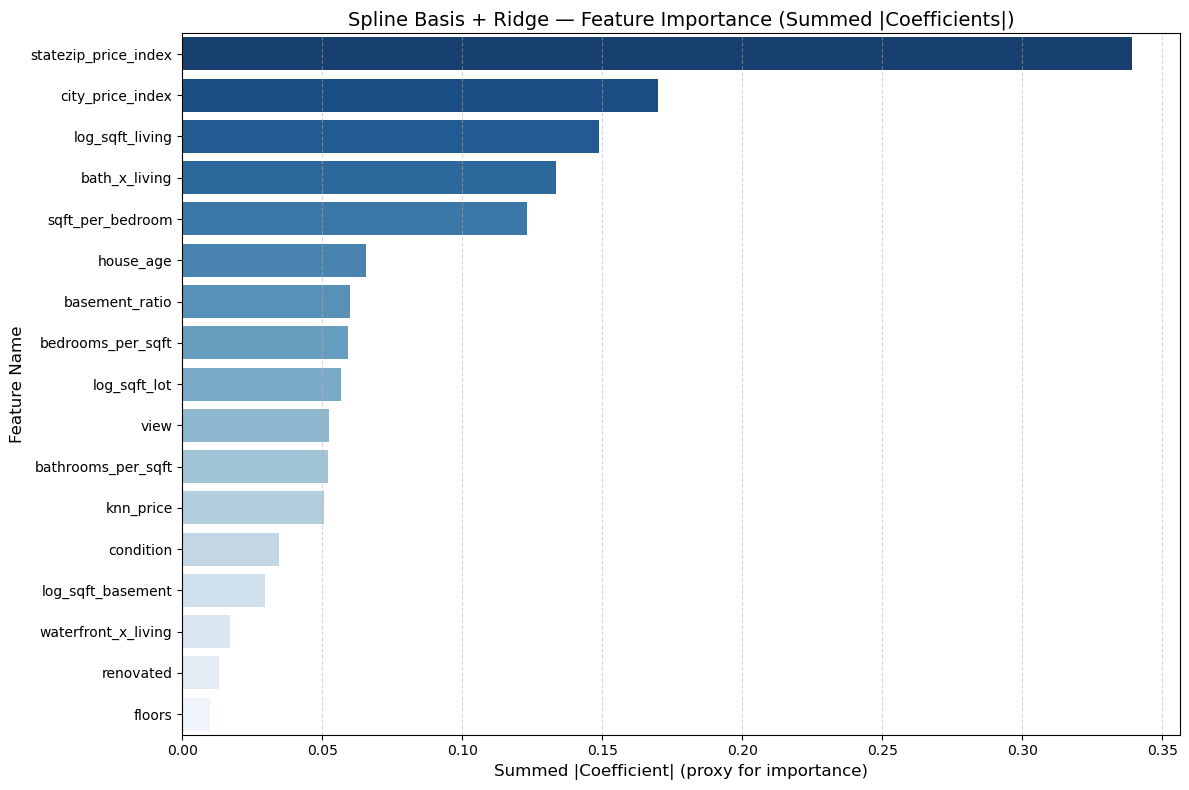

  SPLINE BASIS + RIDGE FEATURE IMPORTANCE (Total: 17 features)
             Feature  Summed |Coefficient|
statezip_price_index              0.339411
    city_price_index              0.169756
     log_sqft_living              0.148855
       bath_x_living              0.133646
    sqft_per_bedroom              0.123187
           house_age              0.065529
      basement_ratio              0.059732
   bedrooms_per_sqft              0.059363
        log_sqft_lot              0.056574
                view              0.052538
  bathrooms_per_sqft              0.052229
           knn_price              0.050765
           condition              0.034423
   log_sqft_basement              0.029466
 waterfront_x_living              0.017127
           renovated              0.013153
              floors              0.009785


In [9]:
# Feature Importance for the BEST linear model: Spline Basis + Ridge
# Note: Spline transforms expand each continuous feature into multiple basis functions.
# We summarise importance by summing |coefficients| per original feature.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the spline transformer and ridge coefficients
ct = spline_ridge_pipeline.named_steps['ct']
ridge = spline_ridge_pipeline.named_steps['model']
coef = ridge.coef_.flatten()

# 2. Reconstruct feature names after SplineTransformer expansion
spline_transformer = ct.named_transformers_['transform']['spline']
n_knots = spline_transformer.n_knots
degree = spline_transformer.degree
n_spline_per_feature = n_knots + degree - 2  # scikit-learn default

spline_feature_names = []
for col in continuous_cols:
    for k in range(n_spline_per_feature):
        spline_feature_names.append(f'{col}_spline_{k}')

# binary/passthrough features follow directly
all_expanded_names = spline_feature_names + binary_cols

# 3. Aggregate |coef| by original feature
importance_dict = {col: 0.0 for col in list(continuous_cols) + binary_cols}

for name, c in zip(all_expanded_names, coef):
    # match back to original feature
    original = next((col for col in importance_dict if name.startswith(col)), name)
    importance_dict[original] += abs(c)

importance_df = pd.DataFrame(
    list(importance_dict.items()), columns=['Feature', 'Summed |Coefficient|']
).sort_values(by='Summed |Coefficient|', ascending=False).reset_index(drop=True)

# 4. Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importance_df,
    x='Summed |Coefficient|',
    y='Feature',
    hue='Feature',
    palette='Blues_r',
    legend=False
)
plt.title('Spline Basis + Ridge — Feature Importance (Summed |Coefficients|)', fontsize=14)
plt.xlabel('Summed |Coefficient| (proxy for importance)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('=' * 65)
print(f'  SPLINE BASIS + RIDGE FEATURE IMPORTANCE (Total: {len(importance_df)} features)')
print('=' * 65)
print(importance_df.to_string(index=False))
print('=' * 65)

